In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Visulaization

In [2]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(
        format='svg',
        graph_attr={'rankdir': 'LR'}
    )
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(
            name=uid, 
            label=f"{n.label} | data {round(n.data, 4)} | grad {round(n.grad, 4)}", 
            shape='record'
        )
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [3]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return self - other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __pow__(self, k):
        assert isinstance(k, (int, float)), "only supporting int/float in pow()"
        out = Value(self.data ** k, (self,), f'**{k}')
        
        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():
            self.grad += math.exp(x) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out
    
    def sigmoid(self):
        x = self.data
        z = 1 / (1 + math.exp(-x))
        out = Value(z, (self,), "sigmoid")
        
        def _backward():
            self.grad += z * (1 - z) * out.grad
            
        out._backward = _backward
        return out
    
    def relu(self):
        x = self.data
        z = max(0, x)
        out = Value(z, (self,), 'relu')
        
        def _backward():
            self.grad += out.grad * (1 if x > 0 else 0)
        
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


### Neuron, Layers, MLP

In [4]:
import random

class Neuron:
    def __init__(self, nin):
        self.weights = [Value(random.uniform(-1, 1)) for i in range(nin)]
        self.bias = Value(random.uniform(-1, 1))
        
    def __call__(self, x):
        act = sum([wi * xi for wi, xi in zip(self.weights, x)], self.bias)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.weights + [self.bias]
    

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, inputs):
        outs = [neuron(inputs) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        size = [nin] + nouts
        self.layers = [Layer(size[i], size[i + 1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [108]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

n = MLP(3, [4, 4, 1])

In [109]:
for k in range(10000):
    # forward pass
    y_pred = [n(x) for x in xs]
    loss = sum([(ygt - yout)**2 for ygt, yout in zip(ys, y_pred)])
    
    # zero grad
    for p in n.parameters():
        p.grad = 0.0
    
    # backward pass
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    
    print(k, loss.data)

0 8.187881514965586
1 4.119160122292514
2 3.653262542678058
3 3.128296639109866
4 2.84101634734503
5 1.6395361806916564
6 0.8490147034784263
7 0.3334901433390757
8 0.1545465729372563
9 0.09574665741211978
10 0.0688259550028438
11 0.053418461263898716
12 0.04350943489861518
13 0.0366277069864607
14 0.03158203969881208
15 0.027730504953960677
16 0.02469767872030841
17 0.02224980370741178
18 0.02023394513056434
19 0.018545951119207895
20 0.01711249997313697
21 0.01588051422536724
22 0.014810646489040302
23 0.013873123016065988
24 0.013045007684137296
25 0.012308351533094933
26 0.01164891111614386
27 0.011055241944443697
28 0.010518045111906049
29 0.01002968840647417
30 0.00958384994524756
31 0.009175249312902527
32 0.008799442160044415
33 0.008452661474129874
34 0.008131693620031607
35 0.007833780590570676
36 0.007556542231008939
37 0.007297913839468981
38 0.007056095715044505
39 0.006829512070976412
40 0.0066167773484632885
41 0.006416668423383314
42 0.006228101538942494
43 0.00605011305

In [110]:
y_pred

[Value(data=0.9988701499656948),
 Value(data=-0.9985338992767843),
 Value(data=-0.9966724850639499),
 Value(data=0.9976755182645259)]

## Examples

In [2]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c
print(d1)
c += h
d2 = a * b + c

print(d1, d2)
print(f"Slope = {(d2 - d1) / h}")

4.0
4.0 4.0001
Slope = 0.9999999999976694


In [52]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [9]:
L.grad = 1.0

In [11]:
f.grad = 4.0
d.grad = -2.0

In [13]:
# dL/dc = dL/dd * dd/dc
c.grad = -2.0
e.grad = -2.0

In [14]:
# dL/da = dL/de * de/da
a.grad = -2.0 * b.data
b.grad = -2.0 * a.data

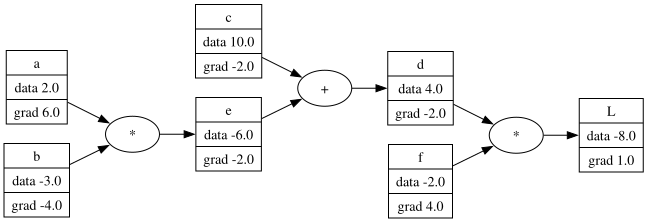

In [55]:
draw_dot(L)

In [54]:
L.backward()

In [16]:
lr = 0.01
a.data += lr * a.grad
b.data += lr * b.grad
c.data += lr * c.grad
f.data += lr * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


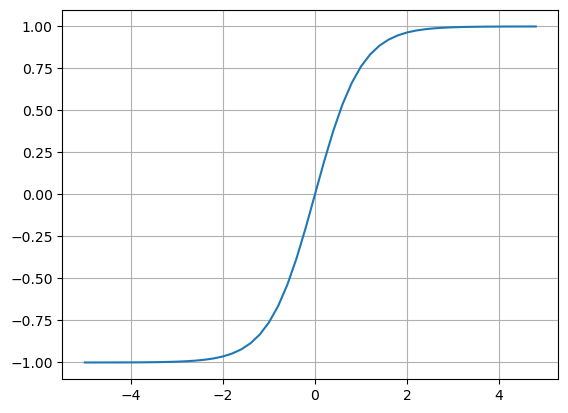

In [17]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

## Backprop in a neurone

In [56]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = 'w1*x1 + w2*x2'
n = w1x1w2x2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [37]:
o.grad = 1.0
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2
n.grad = 1 - o.data ** 2
w1x1w2x2.grad = n.grad
b.grad = n.grad
w1x1.grad = w1x1w2x2.grad
w2x2.grad = w1x1w2x2.grad

x2.grad = w2.data * w2x2.grad
w2.grad = x2.data * w2x2.grad

x1.grad = w1.data * w1x1.grad
w1.grad = x1.data * w1x1.grad

In [58]:
o.backward()

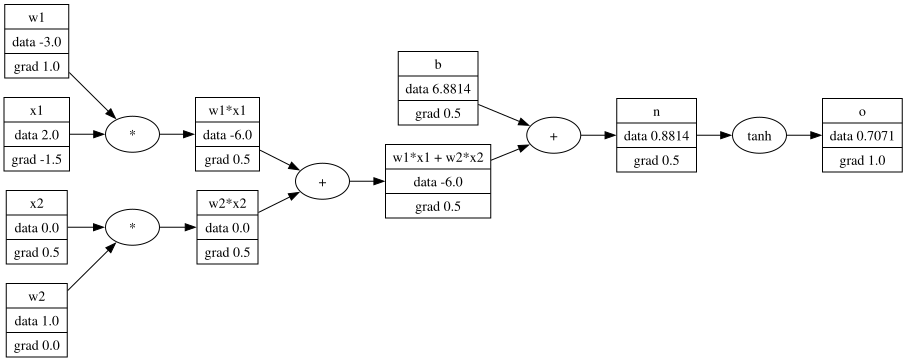

In [59]:
draw_dot(o)

## Operations

In [80]:
a = Value(2.0)
a + 1

Value(data=3.0)

In [81]:
a * 4

Value(data=8.0)

In [82]:
4 * a

Value(data=8.0)

In [76]:
int(4).__rmul__(3)

12

In [86]:
a = Value(4.0)
b = Value(20.0)
b / a

Value(data=5.0)

In [87]:
b - a

Value(data=16.0)

In [88]:
a - b

Value(data=-16.0)

In [91]:
-a

Value(data=-4.0)

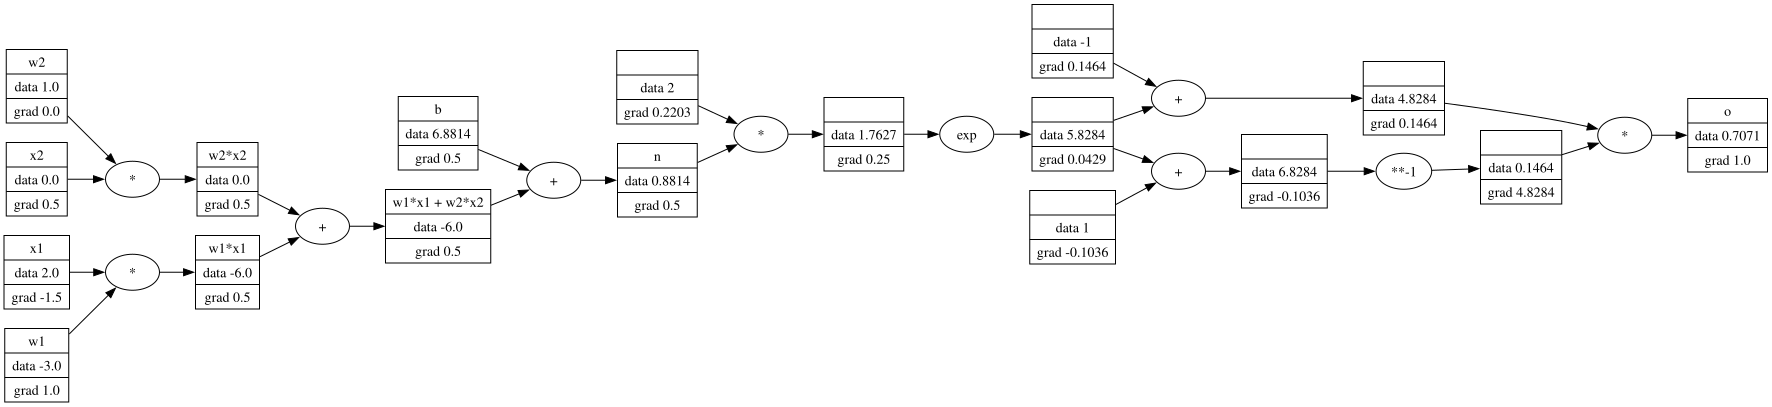

In [112]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = 'w1*x1 + w2*x2'
n = w1x1w2x2 + b; n.label = 'n'

e = (2 * n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

o.backward()
draw_dot(o)

## Pytorch Example

In [98]:
import torch

In [101]:
x1 = torch.tensor([2.0]).double()
x1.requires_grad = True
w1 = torch.tensor([-3.0]).double()
w1.requires_grad = True

x2 = torch.tensor([0.0]).double()
x2.requires_grad = True
w2 = torch.tensor([1.0]).double()
w2.requires_grad = True

b = torch.tensor([6.8813735870195432])
b.requires_grad = True

n = w1 * x1 + w2 * x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print(x1.grad.item(), w1.grad.item())
print(x2.grad.item(), w2.grad.item())
# print(o.grad.item())

0.7071066904050358
-1.5000003851533106 1.0000002567688737
0.5000001283844369 0.0
